In [3]:
#Generate data module 
import numpy as np

# 1GB of 10-bit integers
# Each number is stored as uint16 (2 bytes)
# So 1GB = 1_000_000_000 / 2 = 500_000_000 numbers

N = int(5e8)  # 500 million numbers

print("Generating data...")
data = np.random.randint(0, 1024, size=N, dtype=np.uint16)

print("Saving to file...")
data.tofile("sensor_data.bin")

print(f"Done. Generated {N} numbers, file size = {N*2 / 1e9:.2f} GB")

Generating data...
Saving to file...
Done. Generated 500000000 numbers, file size = 1.00 GB


In [4]:
%%writefile analyser.cpp

#include <iostream>
#include <cstdint>
#include <cstddef>

int analyze_block(const uint16_t* data, size_t count) {
    uint32_t acc = 0;
    
    for (size_t i = 0; i < count; i++) {
        acc |= data[i];
    }
    
    if (acc == 0) return 0;
    
    return 32 - __builtin_clz(acc);
}

Writing analyser.cpp


%%writefile encoder.cpp

#include <cstdint>

//bottleneck giving approx 1gb/s due to nested for loops running

void pack_block(const uint16_t* shuffled_data, int bit_width, uint32_t* output_ptr) {
    
    for (int b = 0; b < bit_width; ++b) {
        uint32_t bit_plane = 0;

        for (int i = 0; i < 32; ++i) {
           
            if (shuffled_data[i * 32 + b] & (1 << b)) {
                
                bit_plane |= (1u << i);
            }
        }
        output_ptr[b] = bit_plane;
    }
}

In [5]:
%%writefile encoder.cpp
#include <cstdint>
#include <immintrin.h> 

void pack_block(const uint16_t* shuffled_data, int bit_width, uint32_t* output_ptr) {
    for (int b = 0; b < bit_width; ++b) {
        __m256i row_part1 = _mm256_loadu_si256((__m256i*)&shuffled_data[b * 32]);
        __m256i row_part2 = _mm256_loadu_si256((__m256i*)&shuffled_data[b * 32 + 16]);

        uint32_t plane_part1 = _mm256_movemask_epi8(_mm256_slli_epi16(row_part1, 15 - b));
        uint32_t plane_part2 = _mm256_movemask_epi8(_mm256_slli_epi16(row_part2, 15 - b));
        
        output_ptr[b] = (plane_part2 << 16) | plane_part1;
    }
}

Writing encoder.cpp


%%writefile block_transpose.cpp

#include <cstdint>

//bottleneck using nested loops

void transpose_32x32(const uint16_t* input, uint16_t* output) {
    for (int i = 0; i < 32; ++i) { 

        for (int j = 0; j < 32; ++j) {
            
            output[j * 32 + i] = input[i * 32 + j];
        }
    }
}

In [7]:
%%writefile block_transpose.cpp
#include <cstdint>
#include <immintrin.h>

void transpose_32x32(const uint16_t* input, uint16_t* output) {
    for (int i = 0; i < 32; i += 8) {
        for (int j = 0; j < 32; j += 8) {
            
            // Load 8 rows of 8 elements (128 bits each)
            __m128i r0 = _mm_loadu_si128((__m128i*)&input[(i + 0) * 32 + j]);
            __m128i r1 = _mm_loadu_si128((__m128i*)&input[(i + 1) * 32 + j]);
            __m128i r2 = _mm_loadu_si128((__m128i*)&input[(i + 2) * 32 + j]);
            __m128i r3 = _mm_loadu_si128((__m128i*)&input[(i + 3) * 32 + j]);
            __m128i r4 = _mm_loadu_si128((__m128i*)&input[(i + 4) * 32 + j]);
            __m128i r5 = _mm_loadu_si128((__m128i*)&input[(i + 5) * 32 + j]);
            __m128i r6 = _mm_loadu_si128((__m128i*)&input[(i + 6) * 32 + j]);
            __m128i r7 = _mm_loadu_si128((__m128i*)&input[(i + 7) * 32 + j]);

            // Stage 1: Unpack 16-bit values (Interleave rows)
            __m128i t0 = _mm_unpacklo_epi16(r0, r1);
            __m128i t1 = _mm_unpackhi_epi16(r0, r1);
            __m128i t2 = _mm_unpacklo_epi16(r2, r3);
            __m128i t3 = _mm_unpackhi_epi16(r2, r3);
            __m128i t4 = _mm_unpacklo_epi16(r4, r5);
            __m128i t5 = _mm_unpackhi_epi16(r4, r5);
            __m128i t6 = _mm_unpacklo_epi16(r6, r7);
            __m128i t7 = _mm_unpackhi_epi16(r6, r7);

            // Stage 2: Unpack 32-bit chunks
            __m128i q0 = _mm_unpacklo_epi32(t0, t2);
            __m128i q1 = _mm_unpackhi_epi32(t0, t2);
            __m128i q2 = _mm_unpacklo_epi32(t1, t3);
            __m128i q3 = _mm_unpackhi_epi32(t1, t3);
            __m128i q4 = _mm_unpacklo_epi32(t4, t6);
            __m128i q5 = _mm_unpackhi_epi32(t4, t6);
            __m128i q6 = _mm_unpacklo_epi32(t5, t7);
            __m128i q7 = _mm_unpackhi_epi32(t5, t7);

            // Stage 3: Unpack 64-bit chunks and Store
            _mm_storeu_si128((__m128i*)&output[(j + 0) * 32 + i], _mm_unpacklo_epi64(q0, q4));
            _mm_storeu_si128((__m128i*)&output[(j + 1) * 32 + i], _mm_unpackhi_epi64(q0, q4));
            _mm_storeu_si128((__m128i*)&output[(j + 2) * 32 + i], _mm_unpacklo_epi64(q1, q5));
            _mm_storeu_si128((__m128i*)&output[(j + 3) * 32 + i], _mm_unpackhi_epi64(q1, q5));
            _mm_storeu_si128((__m128i*)&output[(j + 4) * 32 + i], _mm_unpacklo_epi64(q2, q6));
            _mm_storeu_si128((__m128i*)&output[(j + 5) * 32 + i], _mm_unpackhi_epi64(q2, q6));
            _mm_storeu_si128((__m128i*)&output[(j + 6) * 32 + i], _mm_unpacklo_epi64(q3, q7));
            _mm_storeu_si128((__m128i*)&output[(j + 7) * 32 + i], _mm_unpackhi_epi64(q3, q7));
        }
    }
}

Writing block_transpose.cpp


In [26]:
%%writefile main.cpp
#include <iostream>
#include <fstream>
#include <vector>
#include <chrono>
#include <cstdint>
#include <omp.h>
#include <iomanip>

int analyze_block(const uint16_t* data, size_t count);
void transpose_32x32(const uint16_t* input, uint16_t* output);
void pack_block(const uint16_t* shuffled_data, int bit_width, uint32_t* output_ptr);

struct Telemetry {
    size_t chunk_idx;
    double gbps;
};

int main() {
    std::ifstream file("sensor_data.bin", std::ios::binary);
    if (!file) return 1;

    file.seekg(0, std::ios::end);
    size_t file_size = file.tellg();
    file.seekg(0, std::ios::beg);

    std::vector<uint16_t> data(file_size / 2);
    file.read(reinterpret_cast<char*>(data.data()), file_size);
    file.close();

    std::cout << "Loaded " << file_size / 1e9 << " GB\n";

    uint64_t total_bitwidth = 0;
    std::vector<std::vector<Telemetry>> all_telemetry(omp_get_max_threads());

    auto start = std::chrono::high_resolution_clock::now();

    #pragma omp parallel reduction(+:total_bitwidth)
    {
        int tid = omp_get_thread_num();
        std::vector<uint16_t> local_shuffle(1024);
        uint32_t local_compressed[16];
        
        // Reserve space to avoid reallocation overhead during the hot loop
        all_telemetry[tid].reserve(data.size() / (1024 * omp_get_num_threads()));

        #pragma omp for schedule(static)
        for(size_t i = 0; i < data.size(); i += 1024) {
            auto c_start = std::chrono::high_resolution_clock::now();

            int bit_width = analyze_block(&data[i], 1024);
            total_bitwidth += bit_width;
            transpose_32x32(&data[i], local_shuffle.data());
            pack_block(local_shuffle.data(), bit_width, local_compressed);

            auto c_end = std::chrono::high_resolution_clock::now();
            
            // Log real hardware timing every 50 chunks to keep it fast
            if ((i / 1024) % 50 == 0) {
                double chunk_sec = std::chrono::duration<double>(c_end - c_start).count();
                double chunk_gbps = (2048.0 / 1e9) / chunk_sec;
                all_telemetry[tid].push_back({i, chunk_gbps});
            }
        }
    }

    auto end = std::chrono::high_resolution_clock::now();
    double seconds = std::chrono::duration<double>(end - start).count();

    // Export the REAL data to CSV
    std::ofstream csv("real_telemetry.csv");
    csv << "chunk,gbps\n";
    for (auto& thread_log : all_telemetry) {
        for (auto& entry : thread_log) {
            csv << entry.chunk_idx << "," << entry.gbps << "\n";
        }
    }
    csv.close();

    std::cout << "Total Bit-Sum: " << total_bitwidth << "\n";
    std::cout << "Throughput: " << (file_size / 1e9) / seconds << " GB/s\n";
    std::cout << "Telemetry saved to real_telemetry.csv\n";

    return 0;
}

Overwriting main.cpp


In [37]:
%%writefile baseline.cpp
#include <iostream>
#include <fstream>
#include <vector>
#include <chrono>
#include <cstdint>

int analyze_block_scalar(const uint16_t* data, size_t count) {
    uint32_t acc = 0;
    for (size_t i = 0; i < count; i++) acc |= data[i];
    return (acc == 0) ? 0 : 32 - __builtin_clz(acc);
}

int main() {
    std::ifstream file("sensor_data.bin", std::ios::binary);
    if (!file) {
        std::cerr << "Error: sensor_data.bin not found\n";
        return 1;
    }

    file.seekg(0, std::ios::end);
    size_t file_size = file.tellg();
    file.seekg(0, std::ios::beg);

    std::vector<uint16_t> data(file_size / 2);
    file.read(reinterpret_cast<char*>(data.data()), file_size);
    file.close();

    std::cout << "Loaded " << file_size / 1e9 << " GB\n";

    uint64_t total_bitwidth = 0;
    std::ofstream csv("baseline_telemetry.csv");
    if (!csv.is_open()) {
        std::cerr << "Error: Could not create csv file\n";
        return 1;
    }
    csv << "chunk,gbps\n";

    auto start = std::chrono::high_resolution_clock::now();

    for(size_t i = 0; i < data.size(); i += 1024) {
        auto b_start = std::chrono::high_resolution_clock::now();

        total_bitwidth += analyze_block_scalar(&data[i], 1024);

        auto b_end = std::chrono::high_resolution_clock::now();

        if ((i / 1024) % 50 == 0) {
            double chunk_sec = std::chrono::duration<double>(b_end - b_start).count();
            // 1024 uint16_t = 2048 bytes
            double chunk_gbps = (2048.0 / 1e9) / chunk_sec;
            // std::endl forces a buffer flush to disk every write
            csv << i << "," << chunk_gbps << std::endl; 
        }
    }

    auto end = std::chrono::high_resolution_clock::now();
    csv.close();

    double seconds = std::chrono::duration<double>(end - start).count();
    std::cout << "Sum: " << total_bitwidth << "\n";
    std::cout << "Baseline throughput: " << (file_size / 1e9) / seconds << " GB/s\n";

    return 0;
}

Overwriting baseline.cpp


In [10]:
!lscpu

Architecture:                x86_64
  CPU op-mode(s):            32-bit, 64-bit
  Address sizes:             46 bits physical, 48 bits virtual
  Byte Order:                Little Endian
CPU(s):                      4
  On-line CPU(s) list:       0-3
Vendor ID:                   GenuineIntel
  Model name:                Intel(R) Xeon(R) CPU @ 2.00GHz
    CPU family:              6
    Model:                   85
    Thread(s) per core:      2
    Core(s) per socket:      2
    Socket(s):               1
    Stepping:                3
    BogoMIPS:                4000.41
    Flags:                   fpu vme de pse tsc msr pae mce cx8 apic sep mtrr pg
                             e mca cmov pat pse36 clflush mmx fxsr sse sse2 ss h
                             t syscall nx pdpe1gb rdtscp lm constant_tsc rep_goo
                             d nopl xtopology nonstop_tsc cpuid tsc_known_freq p
                             ni pclmulqdq ssse3 fma cx16 pcid sse4_1 sse4_2 x2ap
                   

In [32]:
!g++ -O3 -march=native -mavx2 -fopenmp main.cpp analyser.cpp block_transpose.cpp encoder.cpp -o high_speed_engine
!./high_speed_engine

Loaded 1 GB
Total Bit-Sum: 4882820
Throughput: 14.0729 GB/s
Telemetry saved to real_telemetry.csv


In [39]:
!g++ -O3 baseline.cpp -o baseline_engine
!./baseline_engine

Loaded 1 GB
Sum: 4882820
Baseline throughput: 5.98778 GB/s


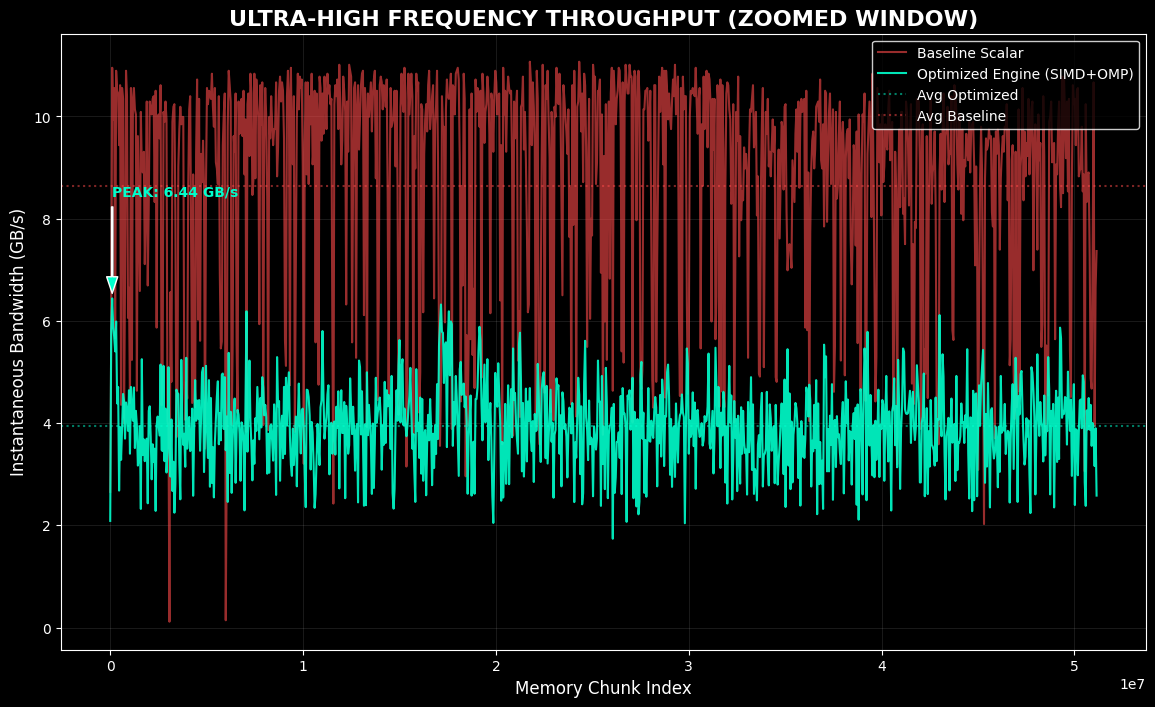

In [42]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the data
df_simd = pd.read_csv('real_telemetry.csv').sort_values('chunk')
df_base = pd.read_csv('baseline_telemetry.csv').sort_values('chunk')

plt.style.use('dark_background')
plt.figure(figsize=(14, 8))

# Define the zoom window (Adjust 'window_size' to see more or less)
window_size = 1000 
df_base_zoom = df_base.head(window_size)
df_simd_zoom = df_simd.head(window_size)

# Plotting with higher line weight for the zoom
plt.plot(df_base_zoom['chunk'], df_base_zoom['gbps'], 
         color='#ff4b4b', label='Baseline Scalar', alpha=0.6, linewidth=1.5)

plt.plot(df_simd_zoom['chunk'], df_simd_zoom['gbps'], 
         color='#00ffcc', label='Optimized Engine (SIMD+OMP)', alpha=0.9, linewidth=1.5)

# Formatting the "Detailed" view
plt.title('ULTRA-HIGH FREQUENCY THROUGHPUT (ZOOMED WINDOW)', fontsize=16, fontweight='bold')
plt.ylabel('Instantaneous Bandwidth (GB/s)', fontsize=12)
plt.xlabel('Memory Chunk Index', fontsize=12)

# Add a horizontal line for the average throughputs
plt.axhline(y=df_simd['gbps'].mean(), color='#00ffcc', linestyle=':', alpha=0.5, label='Avg Optimized')
plt.axhline(y=df_base['gbps'].mean(), color='#ff4b4b', linestyle=':', alpha=0.5, label='Avg Baseline')

plt.legend(loc='upper right', frameon=True, facecolor='black', edgecolor='white')
plt.grid(alpha=0.1)

# Optional: Add a peak annotation
peak_val = df_simd_zoom['gbps'].max()
peak_chunk = df_simd_zoom.loc[df_simd_zoom['gbps'].idxmax(), 'chunk']
plt.annotate(f'PEAK: {peak_val:.2f} GB/s', 
             xy=(peak_chunk, peak_val), xytext=(peak_chunk+50, peak_val+2),
             arrowprops=dict(facecolor='#00ffcc', shrink=0.05, width=1, headwidth=8),
             color='#00ffcc', fontweight='bold')

plt.show()